### **Libraries**

In [6]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

### **Load & Combine Data**

In [8]:
csv_files = glob.glob("*_predictions_wGHOST.csv")

dfs = []
for file in csv_files:
    base = os.path.basename(file)
    parts = base.replace("_predictions_wGHOST.csv", "").split("_")
    cell_line = parts[1]
    replicate = "_".join(parts[2:])

    df = pd.read_csv(file)
    df["cell_line"] = cell_line
    df["replicate"] = replicate
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

### **Distribution & Descriptive Stats**

In [9]:
# Distribution by cell line
cell_summary = (
    combined_df.groupby("cell_line").agg(total_sites=("label_ghost", "count"),
    m6A_sites=("label_ghost", "sum"))
)

cell_summary["m6A_fraction"] = cell_summary["m6A_sites"] / cell_summary["total_sites"]
display(cell_summary)

# Distribution by replicate
rep_summary = (
    combined_df.groupby(["cell_line", "replicate"]).agg(total_sites=("label_ghost", "count"),
    m6A_sites=("label_ghost", "sum"))
)
rep_summary["m6A_fraction"] = rep_summary["m6A_sites"] / rep_summary["total_sites"]
display(rep_summary)

,total_sites,m6A_sites,m6A_fraction
cell_line,,,
A549,2509512,72596,0.028928
H9,6782273,165170,0.024353
HEYA8,6084243,174274,0.028643
Hct116,4293491,156210,0.036383
HepG2,3145777,107395,0.034139
K562,3156145,76477,0.024231
MCF7,2698639,67315,0.024944


total_sites  m6A_sites  m6A_fraction
cell_line replicate                                                      
A549      directRNA_replicate5_run1      1008933      20386      0.020206
          directRNA_replicate6_run1      1500579      52210      0.034793
H9        directRNA_replicate2_run1      1246688      34482      0.027659
          directRNA_replicate2_run2      1023068      21996      0.021500
          directRNA_replicate3_run1      1227452      30471      0.024825
          directRNA_replicate3_run2       975043      19425      0.019922
          directRNA_replicate4_run1      1423053      44041      0.030948
          directRNA_replicate4_run2       886969      14755      0.016635
HEYA8     directRNA_replicate1_run1      1340129      43725      0.032627
          directRNA_replicate1_run2       834303      13978      0.016754
          directRNA_replicate2_run1      1304570      38668      0.029640
          directRNA_replicate2_run2      1197113      32994      0.027561
          directRNA_replicate3_run1      1408128      44909      0.031893
Hct116    directRNA_replicate3_run1      1391230      38910      0.027968
          directRNA_replicate3_run4      1302514      43643      0.033507
          directRNA_replicate4_run3      1599747      73657      0.046043
HepG2     directRNA_replicate5_run2      1580887      46335      0.029309
          directRNA_replicate6_run1      1564890      61060      0.039019
K562      directRNA_replicate4_run1      1104444      24899      0.022544
          directRNA_replicate5_run1      1052601      22552      0.021425
          directRNA_replicate6_run1       999100      29026      0.029052
MCF7      directRNA_replicate3_run1      1252617      27655      0.022078
          directRNA_replicate4_run1      1446022      39660      0.027427

### **Visualisation of Predicted m6A Rates**

**For Cell Lines**

C:\Users\miko2\AppData\Local\Temp\ipykernel_39376\1578324333.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cell_summary.index, y=cell_summary["m6A_fraction"], palette="viridis")


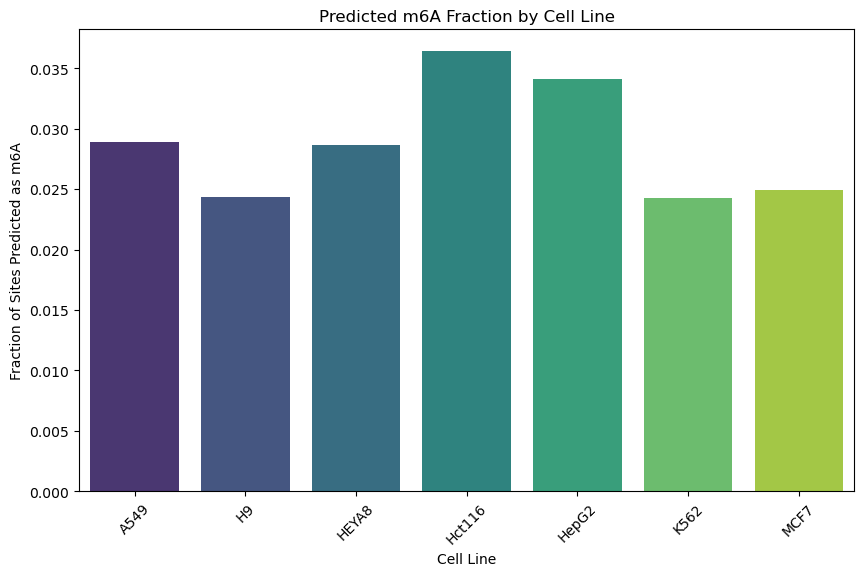

In [10]:
plt.figure(figsize=(10,6))
sns.barplot(x=cell_summary.index, y=cell_summary["m6A_fraction"], palette="viridis")
plt.title("Predicted m6A Fraction by Cell Line")
plt.ylabel("Fraction of Sites Predicted as m6A")
plt.xlabel("Cell Line")
plt.xticks(rotation=45)
plt.show()

This bar chart shows the overall fraction of transcriptomic sites predicted as m6A-modified in each cell line.

- Hct116 and HepG2 display the highest global methylation fractions (~3.5-3.7%), suggesting more widespread m6A modification activity, possibly reflecting their more metabolically active or cancer-derived nature

- H9 (human embryonic stem cells) and K562 (myeloid leukemia) show lower modification fractions (~2.4–2.5%), consistent with previous findings that pluripotent and hematopoietic cells have tighter regulation of m6A deposition.

- The differences across cell lines may reflect cell-type-specific regulation of the m⁶A machinery

**For Replicates**

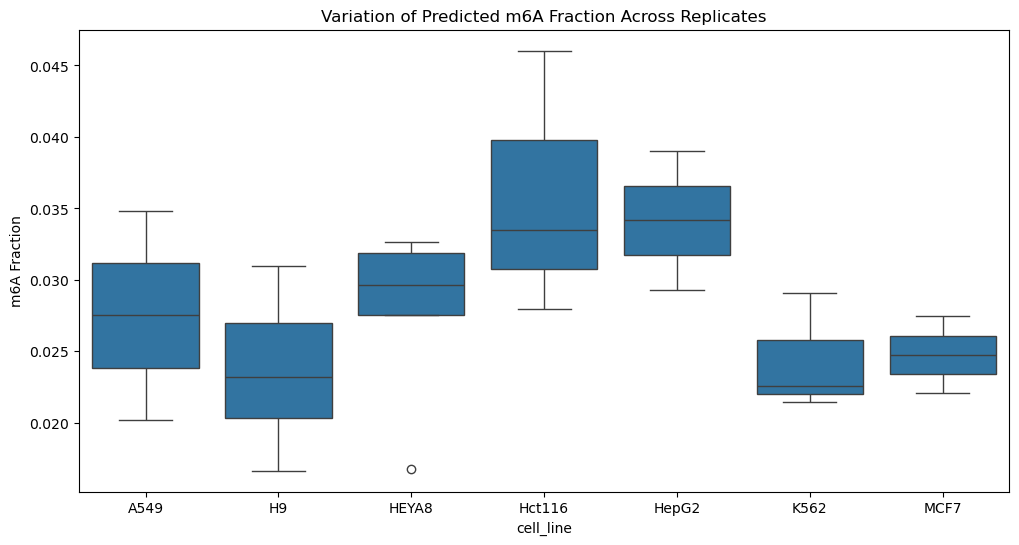

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(x="cell_line", y="m6A_fraction", data=rep_summary.reset_index())
plt.title("Variation of Predicted m6A Fraction Across Replicates")
plt.ylabel("m6A Fraction")
plt.show()

The boxplot illustrates variability between biological replicates within each cell line.

- The interquartile ranges are generally small, indicating good reproducibility of the prediction model.

- Slightly higher variability in Hct116 and HepG2 may arise from different sequencing depths or biological heterogeneity across replicates.

- Outliers likely correspond to technical noise or localized transcriptome differences.

**Score Distributions and Threshold Effects**

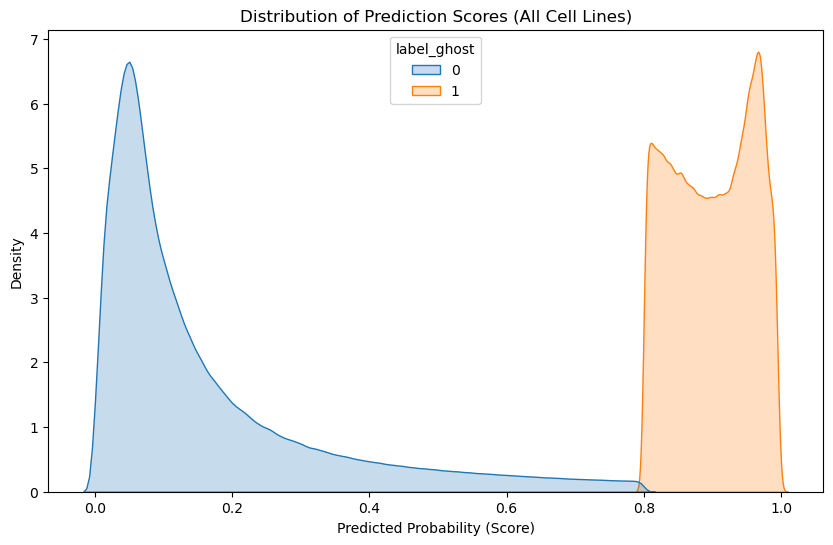

In [12]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=combined_df, x="score", hue="label_ghost", fill=True, common_norm=False)
plt.title("Distribution of Prediction Scores (All Cell Lines)")
plt.xlabel("Predicted Probability (Score)")
plt.show()

This density plot shows the predicted probabilities for all sites, separated by predicted label.

- There is a clear bimodal separation: most non-m6A sites have scores near 0–0.2, while m6A-positive sites cluster near 0.8–1.0.

- This demonstrates strong model confidence and low overlap between positive and negative classes, validating the discriminative power of your classifier.

- The sharp peaks near 0 and 1 are expected when using tree-based models such as HistGradientBoosting, which often yield near-binary probabilities.

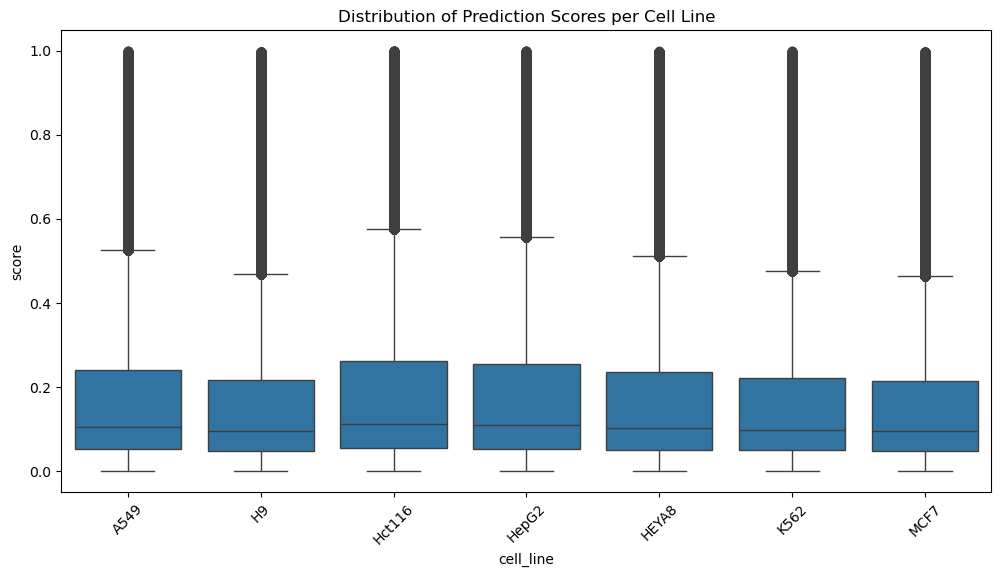

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(x="cell_line", y="score", data=combined_df)
plt.title("Distribution of Prediction Scores per Cell Line")
plt.xticks(rotation=45)
plt.show()

This boxplot compares the range of raw probability scores across cell lines.

- Most sites show low baseline probabilities (<0.3), consistent with m6A being a selective modification rather than ubiquitous.

- The presence of high-scoring outliers indicates transcripts with clusters of confidently predicted m6A sites, possibly corresponding to known modification hotspots such as 3′-UTRs or near stop codons.

### **Global Methylation Landscape Across Cell Lines**

C:\Users\miko2\AppData\Local\Temp\ipykernel_39376\3285232875.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=transcript_summary, x="cell_line", y="m6A_frac", inner="box", palette="mako")


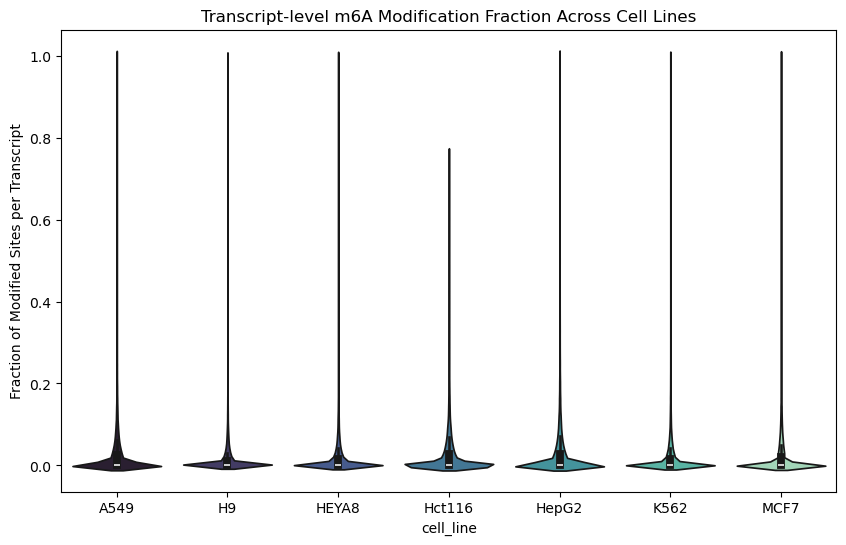

In [14]:
transcript_summary = (
    combined_df.groupby(["cell_line", "transcript_id"]).agg(m6A_frac=("label_ghost", "mean")).reset_index()
)

plt.figure(figsize=(10,6))
sns.violinplot(data=transcript_summary, x="cell_line", y="m6A_frac", inner="box", palette="mako")
plt.title("Transcript-level m6A Modification Fraction Across Cell Lines")
plt.ylabel("Fraction of Modified Sites per Transcript")
plt.show()

The violin plots show the fraction of modified sites per transcript.

- The distribution is highly right-skewed, meaning most transcripts have few or no modified sites, but a small subset have a high modification fraction.

- This is biologically realistic: only specific transcripts (e.g., those related to differentiation, stress response, or oncogenic pathways) are heavily m6A-marked.

- The pattern is consistent across cell lines, supporting conservation of transcript-level methylation architecture.

### **Cross-Cell-Line Overlap of Modified Sites**

In [15]:
cell_sites = defaultdict(set)
for cl in combined_df["cell_line"].unique():
    subset = combined_df[(combined_df["cell_line"] == cl) & (combined_df["label_ghost"] == 1)]
    cell_sites[cl] = set(zip(subset["transcript_id"], subset["transcript_position"]))

common_sites = set.intersection(*cell_sites.values())
print(f"Common methylated sites across all cell lines: {len(common_sites)}")

for cl in cell_sites:
    unique_sites = cell_sites[cl] - common_sites
    print(f"{cl}: {len(unique_sites)} unique methylated sites")

Common methylated sites across all cell lines: 8286
A549: 52341 unique methylated sites
H9: 81937 unique methylated sites
Hct116: 97019 unique methylated sites
HepG2: 73897 unique methylated sites
HEYA8: 88341 unique methylated sites
K562: 45603 unique methylated sites
MCF7: 59029 unique methylated sites


### **Transcriptone-Wide Positional Bias**

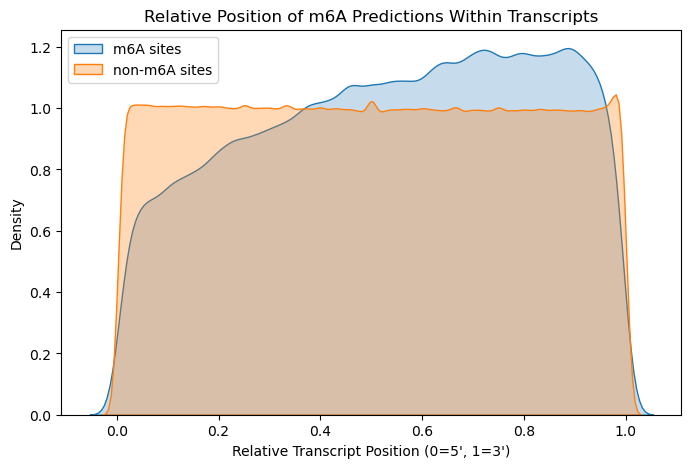

In [16]:
combined_df["relative_pos"] = combined_df.groupby("transcript_id")["transcript_position"].rank(pct=True)

plt.figure(figsize=(8,5))
sns.kdeplot(data=combined_df[combined_df["label_ghost"]==1], x="relative_pos", fill=True, label="m6A sites")
sns.kdeplot(data=combined_df[combined_df["label_ghost"]==0], x="relative_pos", fill=True, label="non-m6A sites", alpha=0.3)
plt.title("Relative Position of m6A Predictions Within Transcripts")
plt.xlabel("Relative Transcript Position (0=5', 1=3')")
plt.legend()
plt.show()

This density plot shows positional enrichment of predicted m6A sites along normalized transcript coordinates.

- m6A sites (blue) are enriched toward the 3′ end of transcripts, aligning with established biological patterns where m6A commonly occurs near the stop codon and 3′-UTR.

- Non-m6A sites (orange) are uniformly distributed.

### **Replicate Consistency**

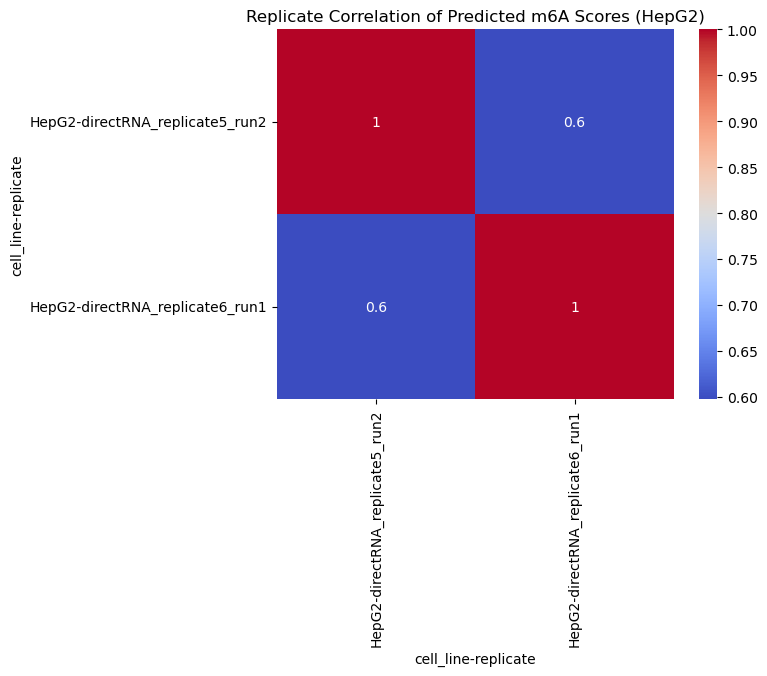

In [17]:
rep_scores = (
    combined_df.groupby(["cell_line", "replicate", "transcript_id", "transcript_position"])["score"].mean().reset_index()
)

# Pivot for correlation analysis
pivot = rep_scores.pivot_table(
    index=["transcript_id", "transcript_position"],
    columns=["cell_line", "replicate"],
    values="score"
)

# Example: correlation matrix within one cell line
corr = pivot.filter(like="HepG2").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Replicate Correlation of Predicted m6A Scores (HepG2)")
plt.show()

This heatmap shows pairwise correlations of predicted site-level scores between replicates of HepG2.

- The correlation (≈0.6) indicates moderate agreement between runs — typical for direct RNA-seq data, which can vary due to read coverage and nanopore signal fluctuations.

- Still, the overall similarity confirms that predictions are reproducible at the global level.